In [101]:
tf.keras.backend.clear_session()


## Importing the needed library

In [143]:
import os

from utils import *
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt


from models.Autoencoder import Conv1DDenoiser

## Generating the dataset
The data will contain numbers between 0 and 2pi, the sine function will be defined in rad.
A random uniform error is added to the sine values to give the dataset a bit of variability and see how the model will perform.
The error is centred with a mean of 0 and std 0f 0.1. This is chosen such that 95% of the error is -0.2 and 0.+2.

In [144]:
train_samples = 500
test_samples = 300
val_samples = 100
# Generate data
x_train, s_train = generate_data(num_samples=train_samples)
x_test, s_test = generate_data(num_samples=test_samples)

x_validate, s_validate = generate_data(num_samples=val_samples)

In [14]:
x_train.shape

(500,)

### Reshape for array input

In [26]:
X_train = x_train.reshape(1, train_samples, 1)
S_train = s_train.reshape(1, train_samples, 1)
X_test = x_test.reshape(1, test_samples, 1)
S_test = s_test.reshape(1, test_samples, 1)

X_validate = x_validate.reshape(1, val_samples, 1)
S_validate = s_validate.reshape(1, val_samples, 1)




In [27]:
X_train.shape

(1, 500, 1)

In [145]:
def create_windows(x, s, window_size=10):
    X, Y = [], []
    for i in range(window_size, len(x)):
        X.append(x[i-window_size:i])  # 10 samples (previous 9 + current)
        Y.append(s[i])                # clean target for the current sample
    X = np.array(X)[..., np.newaxis]  # shape: (samples, 10, 1)
    Y = np.array(Y)[..., np.newaxis]  # shape: (samples, 1)
    return X.astype(np.float32), Y.astype(np.float32)



X_train, S_train = create_windows(x_train, s_train)
X_test, S_test = create_windows(x_test, s_test)
X_val, S_val = create_windows(x_validate, s_validate)

In [159]:
print(X_train.shape, S_train.shape)

(490, 10, 1) (490, 1)


## Check how data looks

In [124]:
seq_list = []
for train in X_train:
    # s_pred = model.predict(test)
    seq_list.append(train.mean())
    # for sample in train:
    #     seq_list.append(sample)

In [126]:
len(seq_list)

490

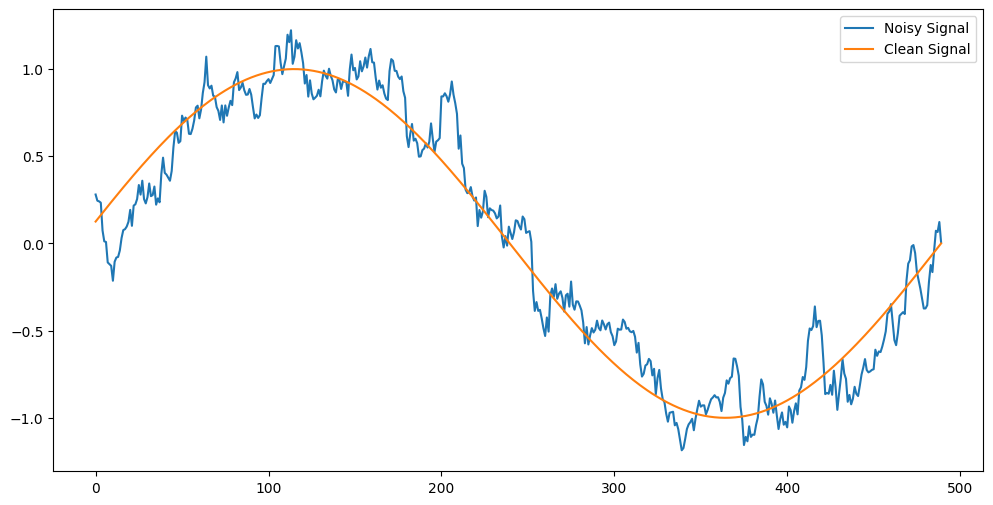

In [127]:
plt.figure(figsize=(12, 6))
plt.plot(seq_list, label='Noisy Signal')
plt.plot(S_train, label='Clean Signal')
plt.legend()

In [148]:
model_name = "seq_input"

In [147]:
def build_realtime_denoiser(window_size=10):
    inp = layers.Input(shape=(window_size, 1))

    # Causal Conv1D (padding='causal' ensures only past context)
    x = layers.Conv1D(16, kernel_size=3, padding='causal', activation='relu')(inp)
    x = layers.Conv1D(8, kernel_size=3, padding='causal', activation='relu')(x)
    x = layers.Conv1D(1, kernel_size=1, padding='valid', activation='linear')(x)

    # Output only the last timestep (current sample)
    out = layers.Lambda(lambda z: z[:, -1, :])(x)
    return Model(inp, out)

In [149]:
if model_name == "autoencoder_filter":
    model = Conv1DDenoiser()
    dummy_input = tf.random.normal([1, 1024, 1])  
    output = model(dummy_input)
    print(output.shape)
elif model_name == "neural_filter":
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(1,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
elif model_name == "adaptive_neural":
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(1,)),
        tf.keras.layers.Conv1D(16, kernel_size=9, padding='same'),
        tf.keras.layers.Dense(1)
    ])
elif model_name == "conv1_no_array":
    model = tf.keras.Sequential([
            tf.keras.layers.Conv1D(16, kernel_size=9, padding='same', activation="relu", input_shape=(1000, 1)),
            tf.keras.layers.Conv1D(32, kernel_size=5, padding='same', activation="relu"),
            tf.keras.layers.Dense(1)
        ])
elif model_name == "conv_downsize":
    model = tf.keras.Sequential([
            tf.keras.layers.Conv1D(16, kernel_size=5, padding='same', activation="relu", input_shape=(500, 1)),
            Dense(1)
        ])
elif model_name == "scalar_conv_input":
    model = tf.keras.Sequential([
            tf.keras.layers.Conv1D(16, kernel_size=5, padding='same', activation="relu", input_shape=(10, 1)),
            Dense(1),
            tf.keras.layers.Lambda(lambda x: x[:, -1, :])
            # tf.keras.layers.Dense(1),
            # tf.keras.layers.Cropping1D(cropping=(9, 0)),  # keep only last timestep
            # tf.keras.layers.Flatten()                     # output shape -> (1,)
        ])
elif model_name == "seq_input":
    model = build_realtime_denoiser(window_size=10)
else:
    # Build the neural network
    model = Sequential([
        Dense(64, activation='relu', input_shape=(1,)),
        Dense(64, activation='relu'),
        Dense(1)
    ])

In [150]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 10, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 10, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 10, 1)          │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

In [151]:
print(X_train.shape, S_train.shape)


(490, 10, 1) (490, 1)


In [158]:
print("X_train:", X_train.shape)
print("S_train:", S_train.shape)
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)


X_train: (490, 10, 1)
S_train: (490, 1)
Model input shape: (None, 10, 1)
Model output shape: (None, 1)


## Normal training

In [153]:
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=["mae"])

# Train the model
history = model.fit(X_train, S_train, epochs=200, batch_size=32, validation_data=(X_validate, S_validate))




Epoch 1/200
 1/16 ━━━━━━━━━━━━━━━━━━━━ 8s 566ms/step - loss: 1.1698 - mae: 0.9444

ValueError: Input 0 of layer "functional_4" is incompatible with the layer: expected shape=(None, 10, 1), found shape=(None, 100)

In [ ]:
# Evaluate the model
# loss = model.evaluate(X_test[0], S_test[0])
# print(f"Test Loss: {loss}")

s_pred = model.predict(X_test)



## New sequence training

In [166]:
import numpy as np

def generate_dataset(n_samples=10000, window=10, fs=1000):
    X, y = [], []
    for _ in range(n_samples):
        f = np.random.uniform(5, 50)        # random frequency
        phase = np.random.uniform(0, 2*np.pi)
        t = np.arange(window) / fs
        clean = np.sin(2*np.pi*f*t + phase)
        noise = np.random.normal(0, 0.2, window)
        noisy = clean + noise
        X.append(noisy)
        y.append(clean[-1])  # current sample target
    X = np.array(X)[..., None]
    y = np.array(y)[..., None]
    return X, y

X, y = generate_dataset()
X_test, y_test = generate_dataset(n_samples=1000)
history = model.fit(X, y, epochs=20, batch_size=64, validation_split=0.1)


Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0161 - mae: 0.0976 - val_loss: 0.0164 - val_mae: 0.0996
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0161 - mae: 0.0977 - val_loss: 0.0164 - val_mae: 0.0980
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0162 - mae: 0.0978 - val_loss: 0.0165 - val_mae: 0.0981
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0161 - mae: 0.0976 - val_loss: 0.0165 - val_mae: 0.1002
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0161 - mae: 0.0975 - val_loss: 0.0165 - val_mae: 0.0994
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0160 - mae: 0.0976 - val_loss: 0.0167 - val_mae: 0.0990
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0160 - mae: 0.0975 - val_loss: 0.0171 - val_mae: 0.0990
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0160 - mae: 0.0973 - val_loss: 0.0167 - val_mae: 0.0982
Epoch 9/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

In [170]:
print(X.shape, y.shape)
print(X_test.shape, y_test.shape)

(10000, 10, 1) (10000, 1)
(1000, 10, 1) (1000, 1)


# Training Results

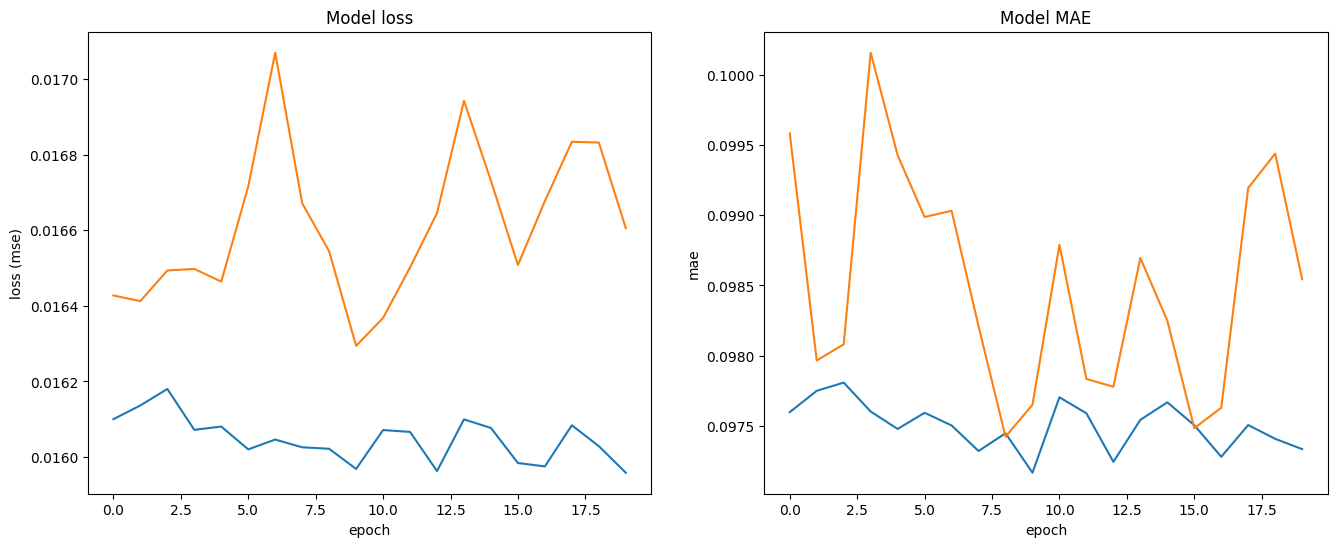

In [167]:
fig, axes = plt.subplots( 1, 2, figsize=(16,6))

axes[0].plot(history.history["loss"], label="training_loss")
axes[0].plot(history.history["val_loss"], label="validation_loss")
axes[0].set_title("Model loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss (mse)")

axes[1].plot(history.history["mae"], label="training_mae")
axes[1].plot(history.history["val_mae"], label="validation_loss")
axes[1].set_title("Model MAE")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mae")

plt.savefig(f'results/{model_name}_training.png')
plt.show()

# Scalar input

ValueError: x and y can be no greater than 2D, but have shapes (1,) and (1, 300, 1)

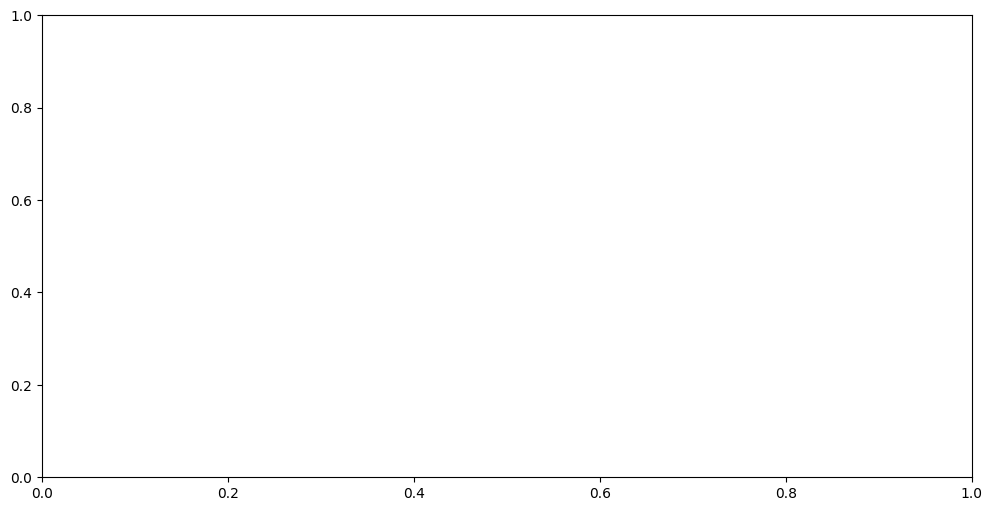

In [133]:
plt.figure(figsize=(12, 6))
plt.plot(x_test, label='Noisy Signal')
plt.plot(s_test, label='Clean Signal')
plt.plot(s_pred, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

# Array input

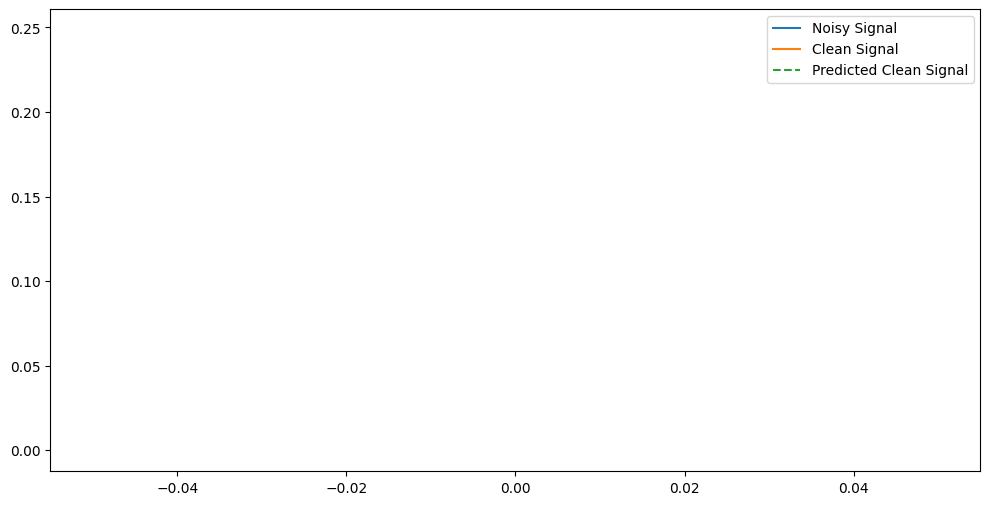

In [70]:
plt.figure(figsize=(12, 6))
plt.plot(x_test[0], label='Noisy Signal')
plt.plot(s_test[0], label='Clean Signal')
plt.plot(s_pred[0], label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

# Sequnce input

In [141]:
seq_list = []
for test in X_test:
    s_pred = model.predict(test)
    seq_list.append(s_pred.mean())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

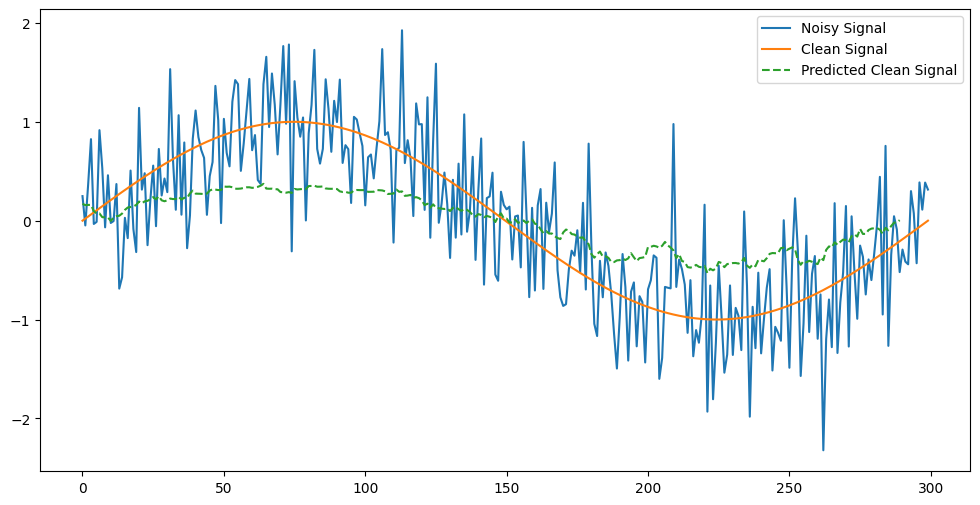

In [142]:
plt.figure(figsize=(12, 6))
plt.plot(x_test, label='Noisy Signal')
plt.plot(s_test, label='Clean Signal')
plt.plot(seq_list, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

# New sequence input

In [168]:
y_pred = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


ValueError: x and y can be no greater than 2D, but have shapes (1000,) and (1000, 10, 1)

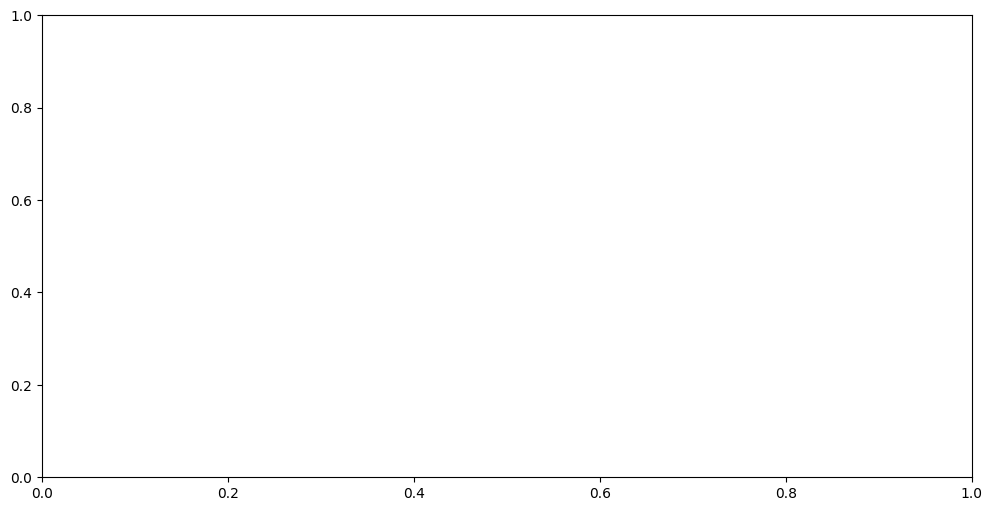

In [169]:
plt.figure(figsize=(12, 6))
plt.plot(X_test, label='Noisy Signal')
plt.plot(y_test, label='Clean Signal')
plt.plot(seq_list, label='Predicted Clean Signal', linestyle='dashed')
plt.legend()
plt.savefig(f'results/{model_name}.png')

## Saving the keras model

In [12]:
model.save(f'checkpoints/{model_name}.keras')


In [80]:
#Loading if needed
model = tf.keras.models.load_model(f'checkpoints/{model_name}.keras')
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 1000, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 1000, 16)       │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1000, 1)        │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,741 (34.15 KB)

 Trainable params: 2,913 (11.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,828 (22.77 KB)

## Converting the model to tflite

In [13]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.optimizations = []
converter.allow_custom_ops = False
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]



# For full integer quantization
def representative_dataset_gen():
  num_calibration_steps = 300
  for _ in range(num_calibration_steps):
    # Get sample input data as a numpy array in a method of your choosing.
    test_data, _ = generate_data(num_calibration_steps)
    test_data.astype(dtype=np.float32)
    yield [test_data]

# Ensure integer input/output
# converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# converter.inference_input_type = tf.int8
# converter.inference_output_type = tf.int8
# converter.representative_dataset = representative_dataset_gen

tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpojdd2p1d/assets


INFO:tensorflow:Assets written to: /tmp/tmpojdd2p1d/assets


Saved artifact at '/tmp/tmpojdd2p1d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 500, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 500, 1), dtype=tf.float32, name=None)
Captures:
  128092221832384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128092221825344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128092221829568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128092221831328: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1759732595.239574   11813 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1759732595.239586   11813 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-10-06 08:36:35.239776: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpojdd2p1d
2025-10-06 08:36:35.240145: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-10-06 08:36:35.240150: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpojdd2p1d
I0000 00:00:1759732595.242708   11813 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2025-10-06 08:36:35.243117: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-10-06 08:36:35.256428: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpojdd2p1d
2025-10-06 08:36:35.261250: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

In [89]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Only built-in ops, no TF ops
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

# Optional: quantization to int8 for STM32
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("conv1d_micro.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpm3nsr9ro/assets


INFO:tensorflow:Assets written to: /tmp/tmpm3nsr9ro/assets


Saved artifact at '/tmp/tmpm3nsr9ro'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 1024, 1), dtype=tf.float32, name=None)
Captures:
  131799532392288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532403728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532390352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532390704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532389296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532318640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532311248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131799532309488: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1759318462.099958  108484 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1759318462.099975  108484 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-10-01 13:34:22.100176: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpm3nsr9ro
2025-10-01 13:34:22.101109: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-10-01 13:34:22.101119: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpm3nsr9ro
2025-10-01 13:34:22.106853: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-10-01 13:34:22.139025: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpm3nsr9ro
2025-10-01 13:34:22.148521: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 48348 microseconds.


## Converting the model to the c, TFlite micro format for the microcontroller

In [137]:
# Save as .tflite file
with open(f"results/{model_name}.tflite", "wb") as file:
    file.write(tflite_model)

with open(f"{model_name}.tflite", "wb") as file:
    file.write(tflite_model)

# Breaking the byte in several lines to fit better in the c header file
tflite_model_split_line = np.array_split([format(hex_value, '#04x') for hex_value in tflite_model], len(tflite_model)//8)

C_HEADER_DIR = "STM_project"
newline = ",\n    "  # separator to avoid new line character

# Write TfLite model to a C header file
open(f"{C_HEADER_DIR}/{model_name.lower()}.h", "w").write(
f"""
#ifndef {model_name.upper()}_H
#define {model_name.upper()}_H

const unsigned int {model_name.lower()}_len = {len(tflite_model)};

const unsigned char {model_name.lower()}[{len(tflite_model)}] = {{
    {newline.join([", ".join(line) for line in tflite_model_split_line])}
}};

#endif // {model_name.upper()}_H
"""
)


17925

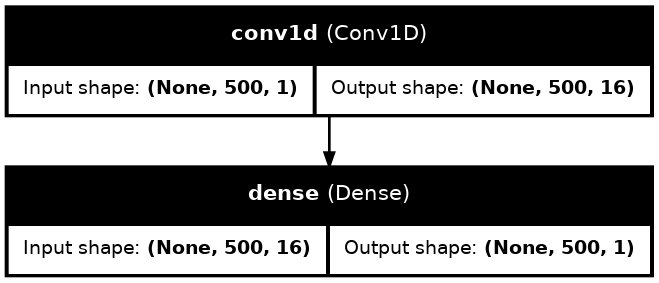

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model,
           to_file='model.png',
           show_shapes=True,
           show_layer_names=True,
           expand_nested=True,   # show inner layers if nested
           dpi=96)
